In [53]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [3]:
len(words)

32033

In [4]:
from string import ascii_lowercase
stoi = {s: i+1 for i, s in enumerate(ascii_lowercase)}
stoi['$'] = 0

itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)

Building Datasets for Train, Validation, and Test

In [ ]:
block_size = 3

def build_dataset(words):
    X, y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '$':
            ix = stoi[ch]
            X.append(context)
            y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X, y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, y_train = build_dataset(words[:n1])
X_valid, y_valid = build_dataset(words[n1:n2])
X_test, y_test = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb),                 generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden),     generator=g)
B1 = torch.randn(n_hidden,                           generator=g)
W2 = torch.randn((n_hidden, vocab_size),             generator=g)
B2 = torch.randn(vocab_size,                         generator=g)

parameters = [C, W1, B1, W2, B2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

11897


In [7]:
max_steps = 200000
batch_size = 32
lossi = []

for epoch in range(max_steps):

    # Mini Batch Construct
    ix = torch.randint(0, X_train.shape[0], (batch_size, ), generator=g)
    X_batch, y_batch = X_train[ix], y_train[ix]

    # Forward Pass
    embeddings = C[X_batch]
    embeddings_concatenated = embeddings.view(embeddings.shape[0], -1)
    hp_react = embeddings_concatenated @ W1 + B1
    h = torch.tanh(hp_react)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits, y_batch)

    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update Step
    lr = 0.1 if epoch < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # Track Status
    if epoch%10000 == 0:
        print(f'{epoch:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 27.8817
  10000/ 200000: 2.9184
  20000/ 200000: 2.5847
  30000/ 200000: 2.7859
  40000/ 200000: 2.0222
  50000/ 200000: 2.6171
  60000/ 200000: 2.3168
  70000/ 200000: 2.0853
  80000/ 200000: 2.2519
  90000/ 200000: 2.2718
 100000/ 200000: 2.0234
 110000/ 200000: 2.4689
 120000/ 200000: 1.9426
 130000/ 200000: 2.3817
 140000/ 200000: 2.3213
 150000/ 200000: 2.1416
 160000/ 200000: 2.2320
 170000/ 200000: 1.7736
 180000/ 200000: 2.0826
 190000/ 200000: 1.8465


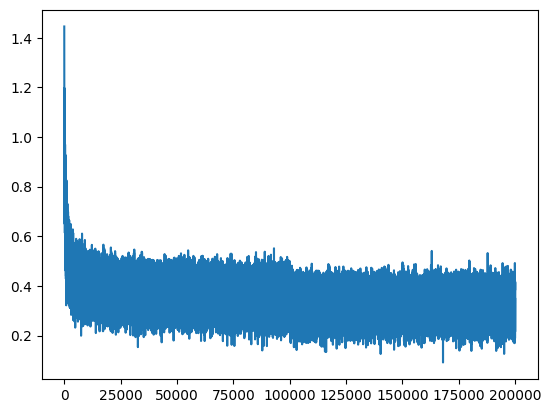

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, y_train),
        'valid': (X_valid, y_valid),
        'test': (X_test, y_test),
    }[split]
    embeddings = C[x]
    h = torch.tanh(embeddings.view(embeddings.shape[0], -1) @ W1 + B1)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('valid')

train 2.1276261806488037
valid 2.1701834201812744


In [10]:
# Sample from the Model
g = torch.Generator().manual_seed(2147483647)
for _ in range(10):
    out = []
    context = [0] * block_size
    while True:
        embeddings = C[torch.tensor([context])]
        h = torch.tanh(embeddings.view(1, -1) @ W1 + B1)
        logits = h @ W2 + B2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        out.append(ix)
        context = context[1:] + [ix]
        if ix == 0:
            break
    print(''.join(itos[x] for x in out[:-1]))

dexzerioulius
rochi
ahnevin
matta
noluwan
kaida
samiyah
jaxhrusotai
moziellah
jacoreda


In [11]:
# The loss we can expect is -> At the worst case scenario all the 27 next characters probabilites are equal means they follow uniform distribution

print(-torch.tensor(1/27).log()) # for single sample
n = 32 # lets say
-torch.tensor(n*[1/27]).log().mean() # Same as single sample loss

tensor(3.2958)


tensor(3.2958)

In [12]:
# But in the training for the first epoch we got `0/ 200000: 27.8817` loss
# So there is something wrong in the initialization of parameters
# The loss we expect is to be tensor(3.2958) but instead we got tensor(27.8817)

In [13]:
# Lets take a uniform distribution example
logits_a = torch.tensor([0.0, 0.0, 0.0, 0.0])
probs = torch.softmax(logits_a, dim=0)
loss = -probs[2].log() # Character character's predicted loss
print(probs, loss) # Uniform loss

logits_a = torch.tensor([0.0, 0.0, 5.0, 0.0])
probs = torch.softmax(logits_a, dim=0)
loss = -probs[2].log() # Character character's predicted loss
print(probs, loss) # Low loss

logits_a = torch.tensor([0.0, 5.0, 0.0, 0.0])
probs = torch.softmax(logits_a, dim=0)
loss = -probs[2].log() # Character character's predicted loss
print(probs, loss) # High loss

logits_a = torch.randn(4) * 10
probs = torch.softmax(logits_a, dim=0)
loss = -probs[2].log()
print(logits_a, '\n',
      probs, '\n',
      loss)

logits_a = torch.randn(4) * 100
probs = torch.softmax(logits_a, dim=0)
loss = -probs[2].log()
print(logits_a, '\n',
      probs, '\n',
      loss)

tensor([0.2500, 0.2500, 0.2500, 0.2500]) tensor(1.3863)
tensor([0.0066, 0.0066, 0.9802, 0.0066]) tensor(0.0200)
tensor([0.0066, 0.9802, 0.0066, 0.0066]) tensor(5.0200)
tensor([  9.3438,  -4.6319,  -0.6052, -12.9827]) 
 tensor([9.9995e-01, 8.5194e-07, 4.7775e-05, 2.0124e-10]) 
 tensor(9.9490)
tensor([-196.9924,  -36.5403,    3.6161,   26.3580]) 
 tensor([0.0000e+00, 4.8262e-28, 1.3283e-10, 1.0000e+00]) 
 tensor(22.7420)


### Goal is to get a minimum loss at the initialization stage of training.

In [14]:
logits[0] # Here the logits are taking quite high values, thats why this creating the fake high loss at initialization after the first epoch, model will do backpropogation and then it will eventually get down to minimal loss because the logits will be updated much much equal to 0, 1, -1 like that.

tensor([ 7.8539,  3.3750,  3.3848,  3.5015,  4.5821,  3.9659,  1.5548,  3.0008,
         5.7546,  5.3703,  3.2080,  3.8544,  6.2126,  4.1155,  7.8451,  1.3288,
         2.4785, -1.1488,  5.4006,  4.3880,  3.8265,  3.7136,  3.2449,  2.8782,
         0.3357,  4.9563,  1.8350], grad_fn=<SelectBackward0>)

In [15]:
# The loss we expect roughly is to be tensor(3.2958) when all the logits are roughly equal and share a uniform distribution

In [16]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb),                 generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden),     generator=g) * 0.2
B1 = torch.randn(n_hidden,                           generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),             generator=g) * 0.01
B2 = torch.randn(vocab_size,                         generator=g) * 0

parameters = [C, W1, B1, W2, B2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

11897


In [17]:
max_steps = 200000
batch_size = 32
lossi = []

for epoch in range(max_steps):

    # Mini Batch Construct
    ix = torch.randint(0, X_train.shape[0], (batch_size, ), generator=g)
    X_batch, y_batch = X_train[ix], y_train[ix]

    # Forward Pass
    embeddings = C[X_batch]
    embeddings_concatenated = embeddings.view(embeddings.shape[0], -1)
    hp_react = embeddings_concatenated @ W1 + B1
    h = torch.tanh(hp_react)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits, y_batch)

    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update Step
    lr = 0.1 if epoch < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # Track Status
    if epoch%10000 == 0:
        print(f'{epoch:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # print(lossi)
    # break

      0/ 200000: 3.3135
  10000/ 200000: 2.1648
  20000/ 200000: 2.3061
  30000/ 200000: 2.4541
  40000/ 200000: 1.9787
  50000/ 200000: 2.2930
  60000/ 200000: 2.4232
  70000/ 200000: 2.0680
  80000/ 200000: 2.3095
  90000/ 200000: 2.1207
 100000/ 200000: 1.8269
 110000/ 200000: 2.2045
 120000/ 200000: 1.9797
 130000/ 200000: 2.3946
 140000/ 200000: 2.1000
 150000/ 200000: 2.1948
 160000/ 200000: 1.8619
 170000/ 200000: 1.7809
 180000/ 200000: 1.9673
 190000/ 200000: 1.8295


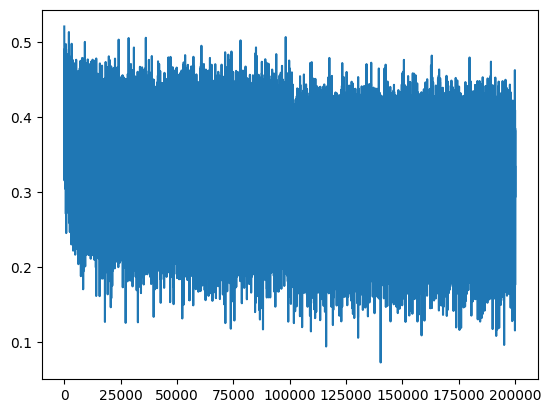

In [18]:
plt.plot(lossi)

In [19]:
split_loss('train')
split_loss('valid')

train 2.0355966091156006
valid 2.1026782989501953


In [20]:
'''
for the first time
27.8817
train 2.1276261806488037
valid 2.1701834201812744

---------------------------------------------------------------------------------------------------------

{B2 * 0}, {W2 * 0} => 
3.2958 # Exactly what we are looking for because all the logits will be zero. so it is a uniform distribution.

{B2 * 0}, {W2 * 0.1} => 
4.2326

---------------------------------------------------------------------------------------------------------

{B2 * 0}, {W2 * 0.01} => 
3.221 # Closely to what we expected but it has little entropy in logits not exactly equal to zero.
train 2.069577217102051
valid 2.131200075149536

---------------------------------------------------------------------------------------------------------

By Fixing Saturated TanH activations
{B1 * 0.01}, {W1 * 0.2} =>
train 2.0355966091156006
valid 2.1026782989501953

---------------------------------------------------------------------------------------------------------

After Kaiming Init
{B1 * 0.01}, {W1 * Gain/sqrt(Fan_In)}
train 2.0376646518707275
valid 2.106989622116089

---------------------------------------------------------------------------------------------------------

Adding Batch Normalization
train 2.0668270587921143
valid 2.104926824569702

 
'''


'\nfor the first time\n27.8817\ntrain 2.1276261806488037\nvalid 2.1701834201812744\n\n---------------------------------------------------------------------------------------------------------\n\n{B2 * 0}, {W2 * 0} => \n3.2958 # Exactly what we are looking for because all the logits will be zero. so it is a uniform distribution.\n\n{B2 * 0}, {W2 * 0.1} => \n4.2326\n\n---------------------------------------------------------------------------------------------------------\n\n{B2 * 0}, {W2 * 0.01} => \n3.221 # Closely to what we expected but it has little entropy in logits not exactly equal to zero.\ntrain 2.069577217102051\nvalid 2.131200075149536\n\n---------------------------------------------------------------------------------------------------------\n\nBy Fixing Saturated TanH activations\n{B1 * 0.01}, {W1 * 0.2} =>\ntrain 2.0355966091156006\nvalid 2.1026782989501953\n\n---------------------------------------------------------------------------------------------------------\n\nAfter

### Fixing Saturatied TanH Actiavation Function

In [21]:
# Now that we are done with the W2 and B2,
# Lets look at activations (h) and pre-activation (hp_react)
# h takes values many in extreme positions
# because
# hp_react (pre-activations) takes extreme values like -20 and 20
# we don't want that

In [22]:
h.shape

torch.Size([32, 200])

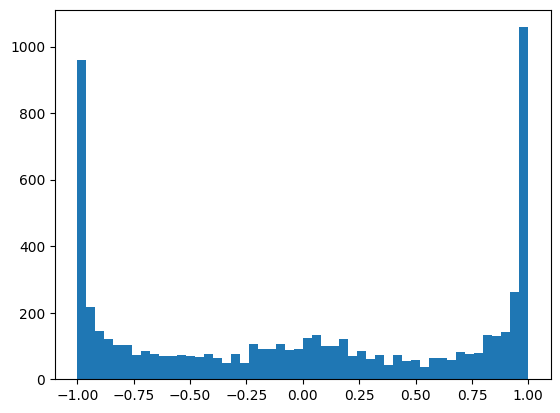

In [23]:
plt.hist(h.view(-1).tolist(), bins=50);

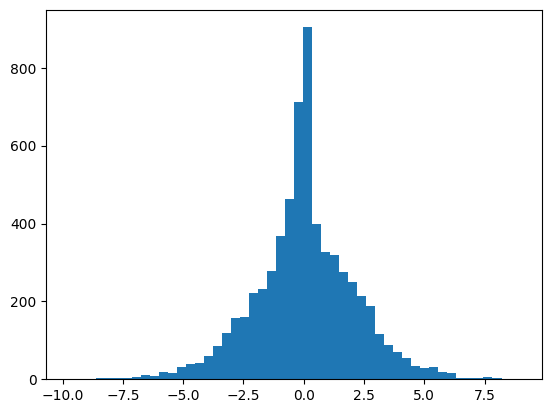

In [24]:
plt.hist(hp_react.view(-1).tolist(), bins=50);

## These pre-activation are very very broad

In [25]:
any((h.abs() > 0.99).sum(dim = 1) == n_hidden) # So there is no Dead Neuron here

False

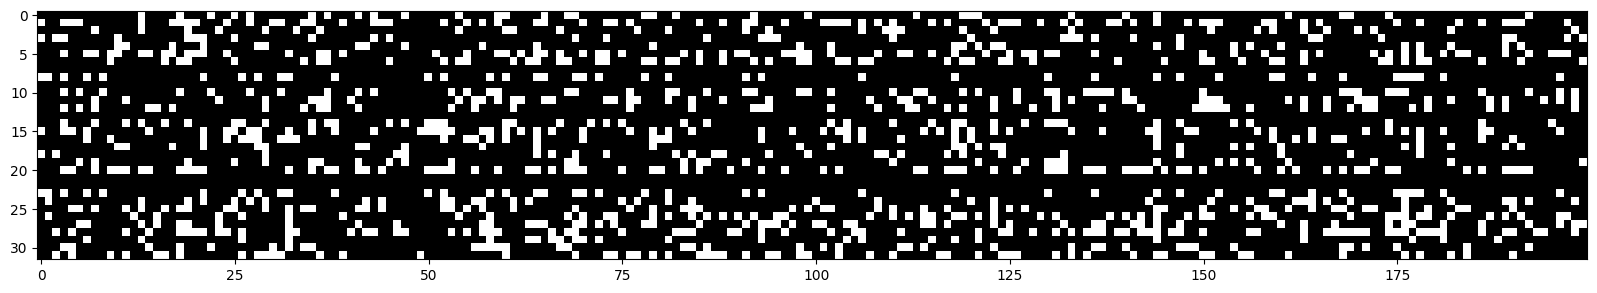

In [26]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

Kaiming Init

In [27]:
print(C.mean(), C.std())
print(W1.mean(), W1.std())

tensor(-0.0655, grad_fn=<MeanBackward0>) tensor(1.1299, grad_fn=<StdBackward0>)
tensor(0.0007, grad_fn=<MeanBackward0>) tensor(0.4373, grad_fn=<StdBackward0>)


In [28]:
embeddings = C[X_batch]
embeddings_concatenated = embeddings.view(embeddings.shape[0], -1)
embeddings_concatenated.mean(), embeddings_concatenated.std()

(tensor(-0.0727, grad_fn=<MeanBackward0>),
 tensor(0.8462, grad_fn=<StdBackward0>))

In [29]:
Z = (embeddings_concatenated @ W1)
print(Z.mean(), Z.std())

W1 = W1 * 0.1
Z = (embeddings_concatenated @ W1)
print(Z.mean(), Z.std())

tensor(0.0345, grad_fn=<MeanBackward0>) tensor(2.0467, grad_fn=<StdBackward0>)
tensor(0.0034, grad_fn=<MeanBackward0>) tensor(0.2047, grad_fn=<StdBackward0>)


In [30]:
# See here in the above all the things are in Normal (Guassian) Distribution, but after the `emb and W1` Multiplied the resultant spread too large.
# We need that to be also similar to Std = 1 (approx.), so that the hp_react won't take too large values
# Thats why we did like W1 * 0.1 or W1 * 0.2
# We need some exact number which gives resultant Pre_Activations hp_react has std = 1 (approx.)
# This is where Kaiming Init comes in, we have to multiply the Weights with gain/((fan_in)**0.5)
# https://docs.pytorch.org/docs/stable/nn.init.html#torch.nn.init.kaiming_normal_

In [31]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb),                 generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden),     generator=g) * (5/3) / ((n_emb * block_size) ** 0.5) # * 0.2
B1 = torch.randn(n_hidden,                           generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),             generator=g) * 0.01
B2 = torch.randn(vocab_size,                         generator=g) * 0

parameters = [C, W1, B1, W2, B2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

11897


In [32]:
max_steps = 200000
batch_size = 32
lossi = []

for epoch in range(max_steps):

    # Mini Batch Construct
    ix = torch.randint(0, X_train.shape[0], (batch_size, ), generator=g)
    X_batch, y_batch = X_train[ix], y_train[ix]

    # Forward Pass
    embeddings = C[X_batch]
    embeddings_concatenated = embeddings.view(embeddings.shape[0], -1)
    hp_react = embeddings_concatenated @ W1 + B1
    h = torch.tanh(hp_react)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits, y_batch)

    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update Step
    lr = 0.1 if epoch < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # Track Status
    if epoch%10000 == 0:
        print(f'{epoch:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # print(lossi)
    # break

      0/ 200000: 3.3179
  10000/ 200000: 2.1910
  20000/ 200000: 2.3270
  30000/ 200000: 2.5396
  40000/ 200000: 1.9468
  50000/ 200000: 2.3331
  60000/ 200000: 2.3852
  70000/ 200000: 2.1173
  80000/ 200000: 2.3159
  90000/ 200000: 2.2010
 100000/ 200000: 1.8591
 110000/ 200000: 2.0881
 120000/ 200000: 1.9389
 130000/ 200000: 2.3913
 140000/ 200000: 2.0949
 150000/ 200000: 2.1458
 160000/ 200000: 1.7824
 170000/ 200000: 1.7249
 180000/ 200000: 1.9752
 190000/ 200000: 1.8614


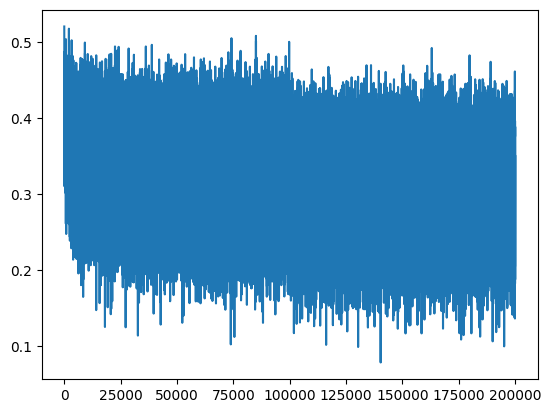

In [33]:
plt.plot(lossi)

In [34]:
split_loss('train')
split_loss('valid')

train 2.0376646518707275
valid 2.106989622116089


### Batch Normalization

In [ ]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb),                 generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden),     generator=g) * (5/3) / ((n_emb * block_size) ** 0.5) # * 0.2
# B1 = torch.randn(n_hidden,                           generator=g) * 0.01 # This Won't do anything because we have bn_bias for hp_react
# there is no use of using Bias for the before layer when using Batch Normalization
W2 = torch.randn((n_hidden, vocab_size),             generator=g) * 0.01
B2 = torch.randn(vocab_size,                         generator=g) * 0

bn_gain = torch.ones((1, n_hidden))
bn_bias = torch.zeros((1, n_hidden))

# after kaiming init hp_react mean = 0, std = 1 (approx.) so now bn_mean_running are zeros and bn_mean_std are ones
bn_mean_running = torch.zeros((1, n_hidden))
bn_std_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, B2, bn_gain, bn_bias]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

12097


In [36]:
max_steps = 200000
batch_size = 32
lossi = []

for epoch in range(max_steps):

    # Mini Batch Construct
    ix = torch.randint(0, X_train.shape[0], (batch_size, ), generator=g)
    X_batch, y_batch = X_train[ix], y_train[ix]

    # Forward Pass
    embeddings = C[X_batch]
    embeddings_concatenated = embeddings.view(embeddings.shape[0], -1)
    # Linear Layer
    hp_react = embeddings_concatenated @ W1 # + B1
    # Batch Normalization Layer
    bn_mean_i = hp_react.mean(dim=0, keepdim=True)
    bn_std_i =  hp_react.std(dim=0, keepdim=True)
    hp_react = bn_gain * ((hp_react - bn_mean_i) / bn_std_i) + bn_bias # here there is no use of B1, because it will be subtracted by bn_mean_i and another bias bn_bias will be added, thats why B1.grad will be zero, so no use of B1
    with torch.no_grad():
        bn_mean_running = 0.999 * bn_mean_running + 0.001 * bn_mean_i
        bn_std_running = 0.999 * bn_std_running + 0.001 * bn_std_i

    # Non-Linearity
    h = torch.tanh(hp_react)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits, y_batch)


    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update Step
    lr = 0.1 if epoch < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # Track Status
    if epoch%10000 == 0:
        print(f'{epoch:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # print(lossi)
    # break

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


In [37]:
# As this is a Batch Normalization
# in hp_react = bn_gain * (hp_react - hp_react.mean(dim=0, keepdim=True) / hp_react.std(dim=0, keepdim=True)) + bn_bias
# this expects batch of size X, because here we are doing statistics methods like mean and std for the batch to normalize the layer right
# that means each values is depending upon other values in a batch for a neuron, neuron_1_01 is dependent on neuron_1_02, n_1_03, n_1_04, ..., n_1_032 => hp_react -> (32, 200) 32 is batch size and 200 neurons are there.

# But in the evaluation or prediction state, we only send one value right like (1, 3, 10) => (1, 30) @ (30, 200) => (1, 200)
# here only 1 batch is there, so what happens to mean and std here.
# thats wny we need a constant bn_mean & bn_std, instead of calculating dynamically

In [38]:
# Calibrate the batch norm at the end of training
with torch.no_grad():
    emb = C[X_train]
    embcat = emb.view(emb.shape[0], -1)
    hp_react = embcat @ W1 + B1
    # Measuring the mean & std over the entire dataset
    bn_mean = hp_react.mean(dim=0, keepdim=True)
    bn_std = hp_react.std(dim=0, keepdim=True)

In [39]:
bn_mean

tensor([[-2.4533e+00,  4.1450e-01, -1.4185e+00,  1.7016e+00,  1.0438e+00,
          5.5778e-01,  2.1393e+00, -1.7455e+00,  1.1729e+00,  1.6132e+00,
         -2.1092e+00, -2.9678e+00,  8.9076e-02, -7.4120e-01,  3.8171e-01,
         -8.0179e-01,  7.2179e-01, -2.7979e+00, -4.3717e-01,  2.0177e+00,
         -8.3360e-01, -8.5357e-02,  5.1543e-02,  3.9955e-01,  1.1621e+00,
          1.4650e+00,  1.1876e+00,  8.2046e-01,  5.0620e-01,  2.0325e+00,
         -4.6832e-01, -1.3510e+00,  4.2545e-02, -5.1513e-01, -3.0538e-01,
         -1.8657e+00, -2.3723e+00, -2.0418e-01, -5.4104e-01,  4.6376e-01,
         -1.6116e-01, -1.0511e+00, -2.0274e-01, -1.5613e-01,  8.1103e-01,
          6.0231e-01,  1.3442e+00, -9.1655e-02,  2.3045e+00,  1.1668e+00,
          1.6326e+00, -8.3695e-01,  2.2630e+00,  3.5629e-01,  7.1997e-01,
         -2.0908e+00, -1.3223e-01,  1.2056e+00,  7.4816e-01, -9.6874e-01,
         -5.5622e-01,  1.1906e+00,  7.0420e-01,  2.8175e-02,  1.4436e+00,
          1.7317e+00, -1.1168e+00,  2.

In [40]:
bn_mean_running

tensor([[-2.4073e+00,  3.7328e-01, -1.2681e+00,  1.2967e+00,  9.6879e-01,
          9.8373e-01,  1.5422e+00, -1.9247e+00,  1.1060e+00,  1.2247e+00,
         -1.8296e+00, -2.7717e+00,  7.1372e-02, -6.1823e-01,  4.3364e-01,
         -6.6872e-01,  7.7061e-01, -2.1881e+00, -2.1887e-01,  1.5706e+00,
         -8.6627e-01,  1.0770e-01, -2.3912e-01,  4.1435e-01,  1.0355e+00,
          1.6324e+00,  1.1980e+00,  9.5799e-01,  3.5301e-01,  1.9479e+00,
         -8.0374e-02, -1.2021e+00, -9.8032e-02, -2.6651e-01, -4.7075e-01,
         -1.4911e+00, -2.6119e+00,  4.6955e-02, -3.0816e-04,  6.0433e-01,
         -2.3633e-01, -9.1247e-01, -2.8293e-01, -1.7835e-01,  6.5023e-01,
          9.0387e-01,  1.5864e+00, -3.9491e-01,  1.9726e+00,  1.0563e+00,
          1.7167e+00, -7.9531e-01,  2.0450e+00,  3.5585e-01,  5.4982e-01,
         -1.9198e+00, -3.1751e-02,  7.1273e-01,  9.0175e-01, -7.9930e-01,
         -6.7666e-01,  9.6928e-01,  4.8910e-01,  2.9599e-01,  1.1424e+00,
          1.6291e+00, -1.3298e+00,  2.

In [41]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, y_train),
        'valid': (X_valid, y_valid),
        'test': (X_test, y_test),
    }[split]
    embeddings = C[x]
    hp_react = embeddings.view(embeddings.shape[0], -1) @ W1 + B1
    hp_react = bn_gain * ((hp_react - bn_mean_running) / bn_std_running) + bn_bias
    h = torch.tanh(hp_react)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('valid')

train 2.103177547454834
valid 2.13948655128479


## In More Cleaner Way

In [ ]:
g = torch.Generator().manual_seed(2147483647)

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / (fan_in ** 0.5)
        self.bias = torch.zeros(fan_out) if bias else None
    def __call__(self, X):
        self.out = X @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1D: 
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # Parameters - training with Backpropogation
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers - trained with a running 'momentum update'
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    def __call__(self, X):
        # Forward Pass
        if self.training:
            X_mean = X.mean(dim=0, keepdim=True) # Batch Mean
            X_var = X.var(dim=0, keepdim=True, unbiased=False) # Batch Variance
            # Update Buffers
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * X_mean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * X_var
        else:
            X_mean = self.running_mean
            X_var = self.running_var
        X_hat = (X - X_mean) / torch.sqrt(X_var + self.eps)
        self.out = self.gamma * X_hat + self.beta
        return self.out
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, X):
        self.out = torch.tanh(X)
        return self.out
    def parameters(self):
        return []

n_emb = 10 # The Dimensionality of the character embedding vectors
n_hidden = 100 # Number of Neurons in the hidden layer of MLP model

C = torch.randn((vocab_size, n_emb), generator=g)

# layers = [
#     Linear(n_emb * block_size, n_hidden), Tanh(),
#     Linear(          n_hidden, n_hidden), Tanh(),
#     Linear(          n_hidden, n_hidden), Tanh(),
#     Linear(          n_hidden, n_hidden), Tanh(),
#     Linear(          n_hidden, n_hidden), Tanh(),
#     Linear(          n_hidden, vocab_size)
# ]

layers = [
    Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size, bias=False), BatchNorm1D(vocab_size)
]


with torch.no_grad():
    # Last Layer needs to be less Confident
    # layers[-1].weight *= 0.1 # As we are adding BatchNorm1D, we need to set gamma not the weights here
    layers[-1].gamma *= 0.1
    # Except the last layer: apply gain to all the layers
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1.0 # (5 / 3) # As we are using BatchNorm1D no need of Gain.

parameters= [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

47024

In [125]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for epoch in range(max_steps):

    # Mini Batch Construct
    ix = torch.randint(0, X_train.shape[0], (batch_size, ), generator=g)
    X_batch, y_batch = X_train[ix], y_train[ix]

    # Forward Pass
    embeddings = C[X_batch]
    X = embeddings.view(embeddings.shape[0], -1)
    for layer in layers:
        X = layer(X)
    loss = F.cross_entropy(X, y_batch)

    # Backward Pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update Step
    lr = 0.1 if epoch < 150000 else 0.01 # Step Learning Rate Decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # Track Status
    if epoch%10000 == 0:
        print(f'{epoch:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10 ().item() for p in parameters])
    # print(lossi)
    if epoch >= 1000:
        break # AFTER_DEBUG: would take out obviously to run full optimization 

      0/ 200000: 3.2868


layer 2 (      Tanh): mean -0.00, std 0.64, saturated: 3.16%
layer 5 (      Tanh): mean +0.00, std 0.65, saturated: 2.66%
layer 8 (      Tanh): mean -0.00, std 0.65, saturated: 2.62%
layer 11 (      Tanh): mean +0.00, std 0.66, saturated: 2.00%
layer 14 (      Tanh): mean +0.00, std 0.66, saturated: 2.16%


Text(0.5, 1.0, 'Activations Distribution')

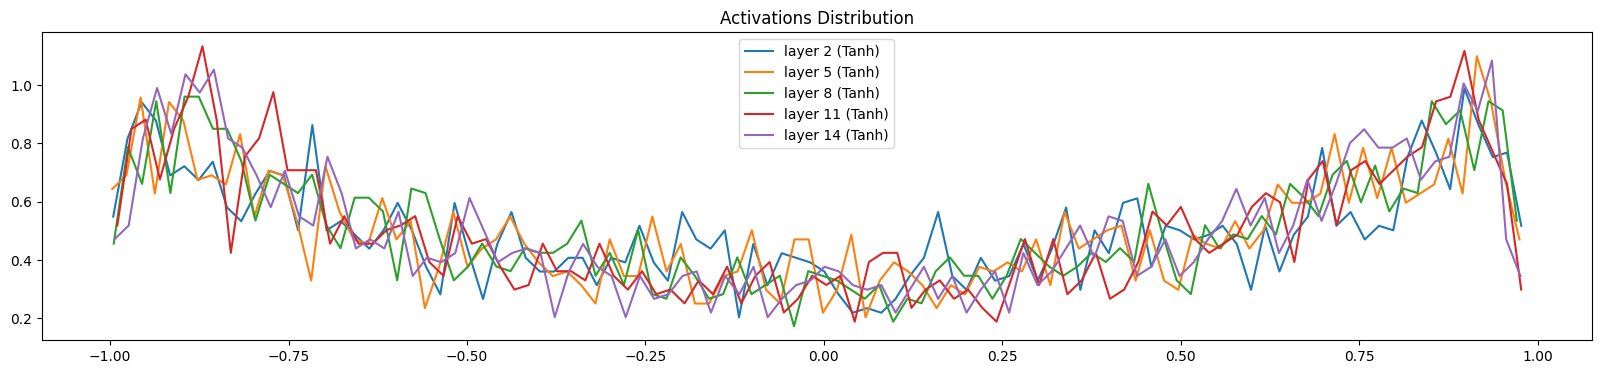

In [126]:
# Visualize histograms
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('Activations Distribution')

layer 1 (      Tanh): mean +0.000024, std 3.353992e-03
layer 3 (      Tanh): mean +0.000012, std 3.157344e-03
layer 5 (      Tanh): mean -0.000004, std 2.925863e-03
layer 7 (      Tanh): mean +0.000036, std 2.715700e-03
layer 9 (      Tanh): mean +0.000020, std 2.308167e-03


Text(0.5, 1.0, 'Gradient Descent Distribution')

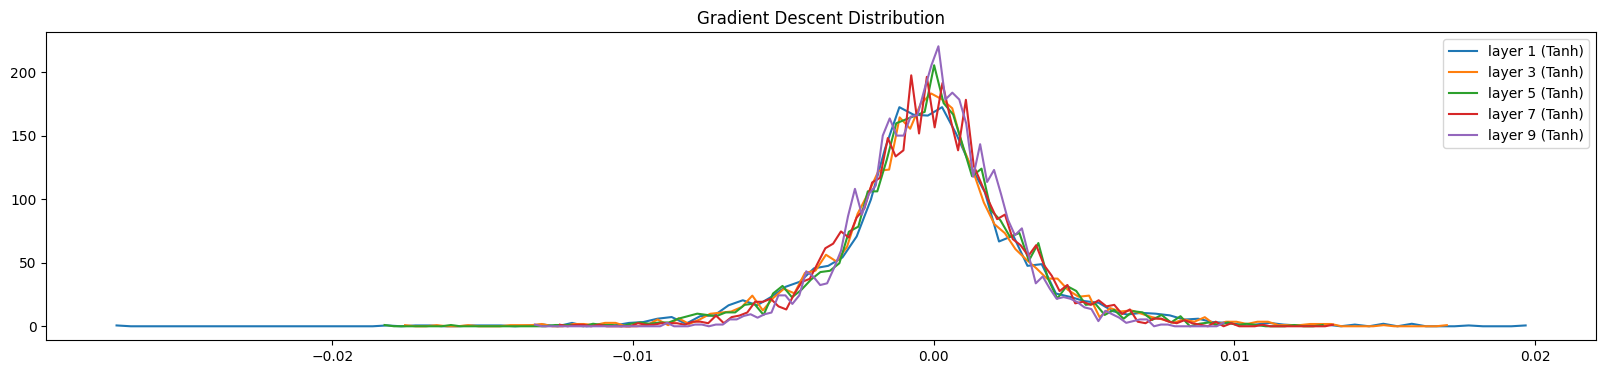

In [122]:
 # Visualize histograms
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('Gradient Descent Distribution')

weights   (27, 10) | mean -0.019306 | std 1.000991e+00 | grad:data ratio: 8.086026e-03
weights  (30, 100) | mean +0.004913 | std 1.893685e-01 | grad:data ratio: 4.892962e-02
weights (100, 100) | mean -0.000632 | std 1.024651e-01 | grad:data ratio: 7.018618e-02
weights (100, 100) | mean +0.000627 | std 1.026783e-01 | grad:data ratio: 6.071783e-02
weights (100, 100) | mean +0.002098 | std 1.019951e-01 | grad:data ratio: 5.665676e-02
weights (100, 100) | mean -0.000549 | std 1.018565e-01 | grad:data ratio: 5.640246e-02
weights  (100, 27) | mean -0.000259 | std 1.043349e-01 | grad:data ratio: 1.163116e-01


Text(0.5, 1.0, 'Weights Gradient Distribution')

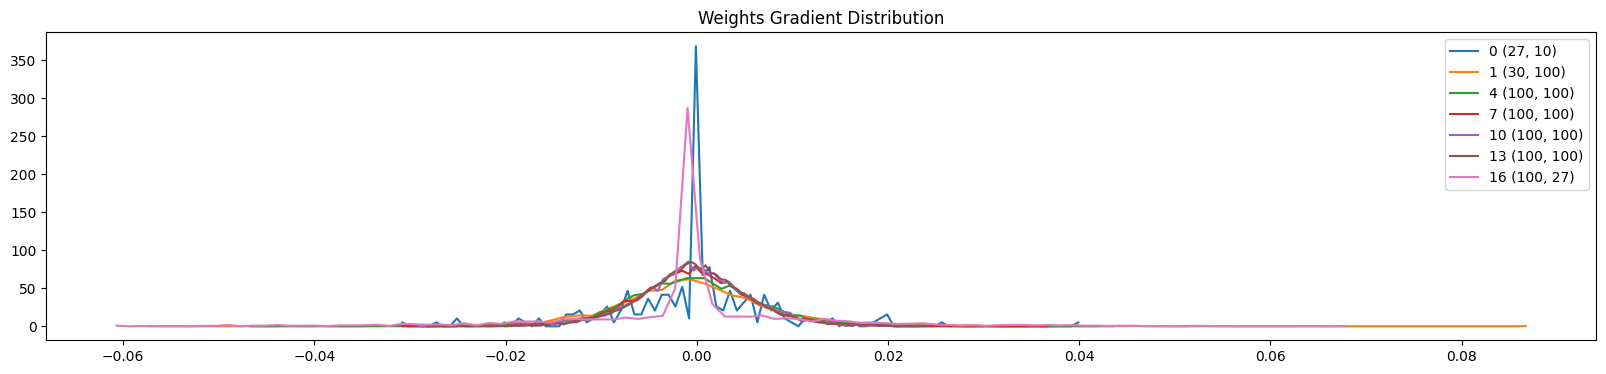

In [127]:
 # Visualize histograms
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weights %10s | mean %+f | std %e | grad:data ratio: %e' % (tuple(p.shape), p.mean(), p.std(), (p.grad.std() / p.data.std())))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('Weights Gradient Distribution')

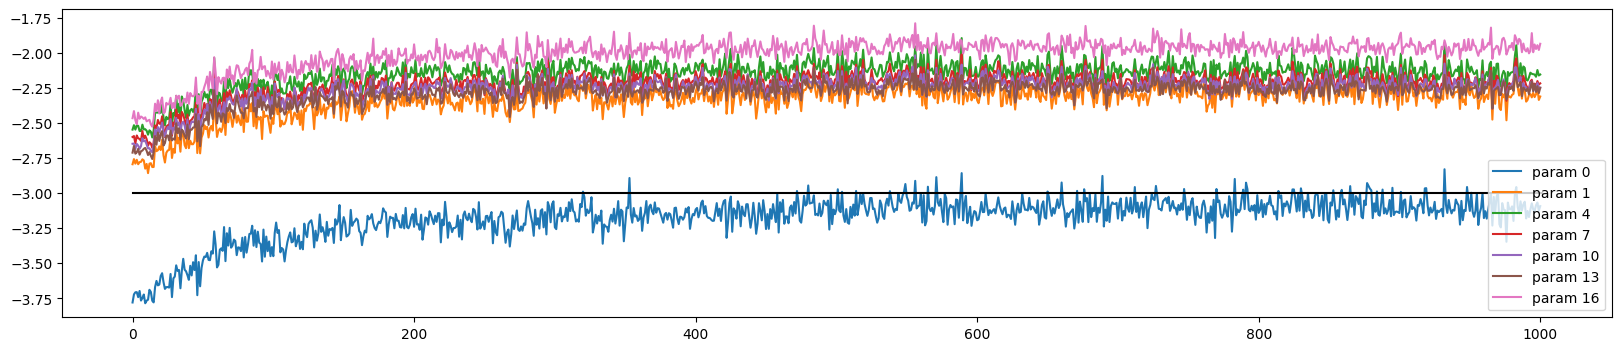

In [ ]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # ideal ratio should be ~1e-3
plt.legend(legends)

# this is like the Gradients are what ratio to the data, like grad = 0.002 and data = 2 then ratio would be 0.001 like this

# if the plotting is above this average ~1e-3 line then the updated i.e learning rate is too high, if the plotting is below the line then
# the learning rate may be too small